# Optimasi Prediksi Churn Pelanggan Telekomunikasi Berdasarkan Pola Penggunaan Layanan dan Perilaku

**Nama** : Iqra Fauzan Akbar  
**NIM** : F1G123020  
**Prodi**: Ilmu Komputer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_excel('Telco_customer_churn.xlsx')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [3]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())


drop_cols = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
             'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Reason','CLTV']
df_clean = df.drop(columns=drop_cols)

le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object', 'string']).columns:
    df_clean[col] = le.fit_transform(df_clean[col])

X = df_clean.drop('Churn Value', axis=1)
y = df_clean['Churn Value']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

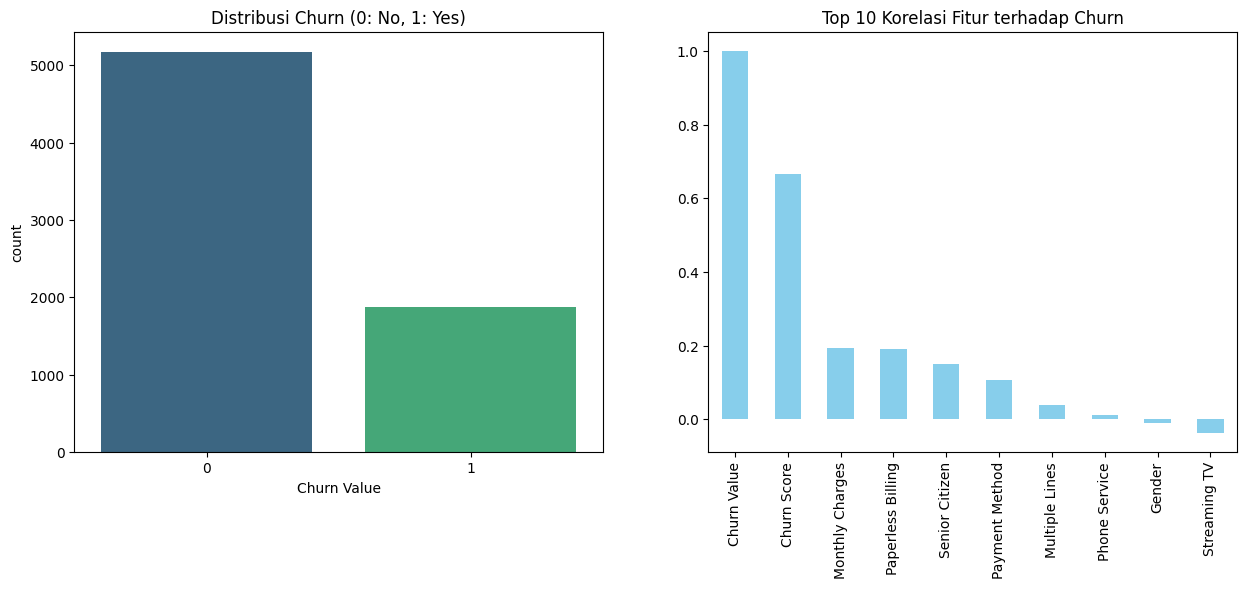

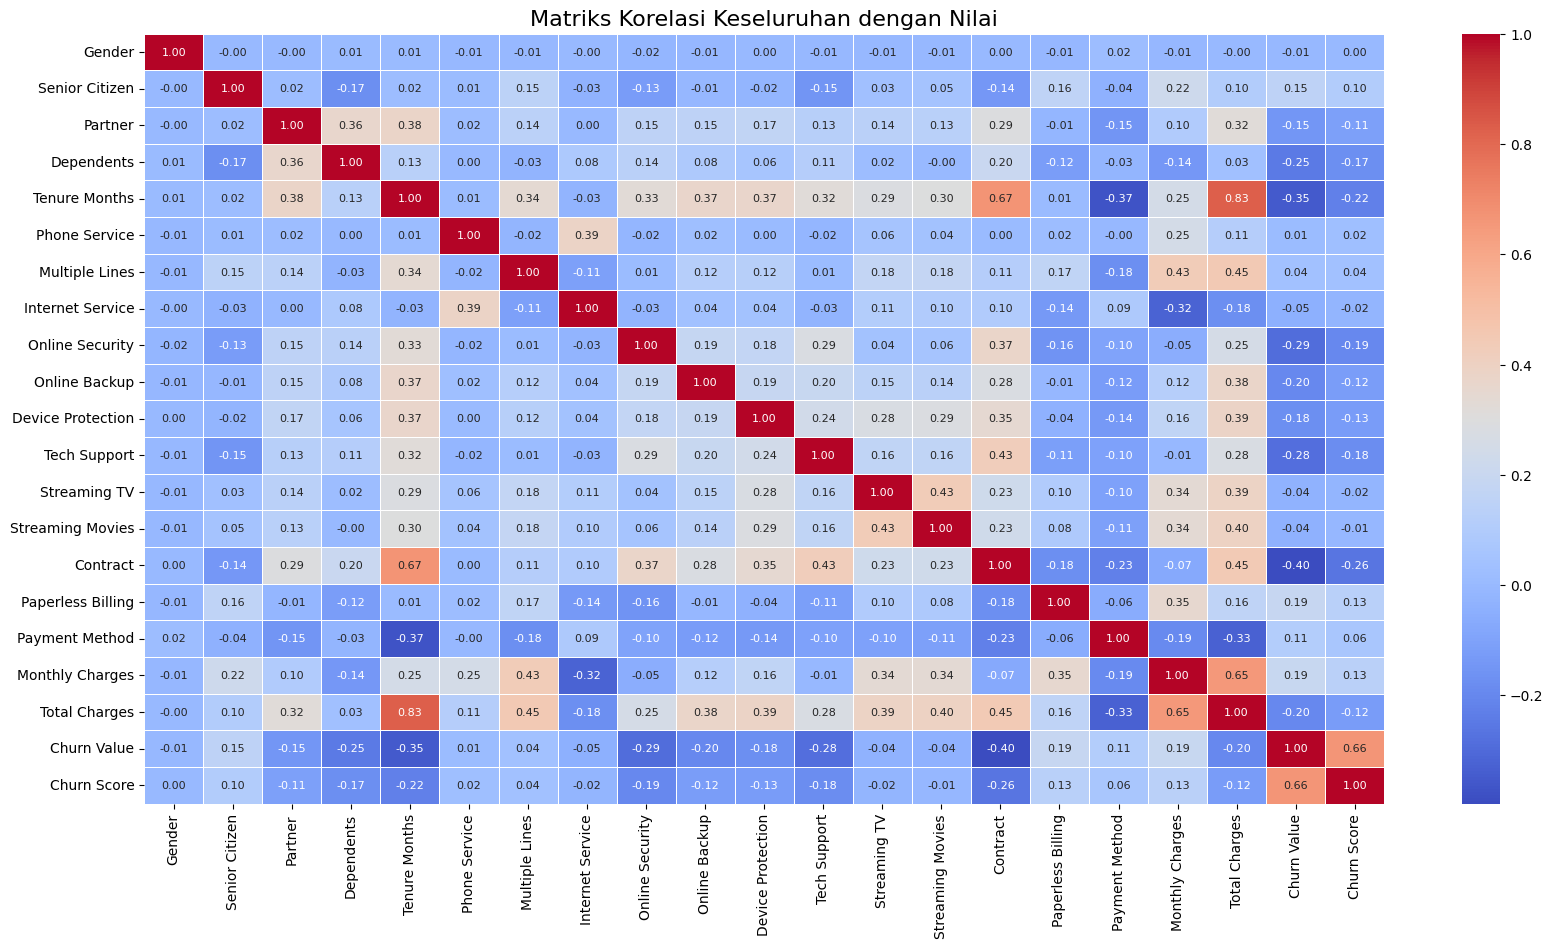

In [4]:
plt.figure(figsize=(15, 12))

# 1. Distribusi Churn
plt.subplot(2, 2, 1)
sns.countplot(x='Churn Value', data=df, hue='Churn Value', palette='viridis', legend=False)
plt.title('Distribusi Churn (0: No, 1: Yes)')

# 2. Bar Chart Korelasi Teratas
plt.subplot(2, 2, 2)
top_corr = df_clean.corr()['Churn Value'].sort_values(ascending=False).head(10)
top_corr.plot(kind='bar', color='skyblue')
plt.title('Top 10 Korelasi Fitur terhadap Churn')

# 3. Heatmap Korelasi (Di baris bawah, memanjang)
plt.figure(figsize=(20, 10)) # Ukuran diperbesar agar angka tidak menumpuk

corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, 
            annot=True,          
            fmt='.2f',          
            cmap='coolwarm',    
            annot_kws={"size": 8}, 
            linewidths=0.5)      

plt.title('Matriks Korelasi Keseluruhan dengan Nilai', fontsize=16)
plt.show()

In [5]:

split_variations = [
    {'train': 0.7, 'test': 0.3},
    {'train': 0.8, 'test': 0.2},
    {'train': 0.9, 'test': 0.1}
]


In [6]:
models_to_run = [
    {
        'name': 'XGBoost',
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [20, 50],
            'max_depth': [6, 10],
            'learning_rate': [0.01, 0.05]
        }
    },
    {
        'name': 'LightGBM',
        'model': LGBMClassifier(random_state=42, verbose=-1),
        'params': {
            'n_estimators': [20, 50],
            'learning_rate': [0.01, 0.05], 
            'num_leaves': [20, 31],        
            'min_child_samples': [20, 30], 
            'reg_alpha': [0.1, 0.5]         
        }
    },
    {
        'name': 'CatBoost',
        'model': CatBoostClassifier(random_state=42, verbose=0),
        'params': {
            'iterations': [20, 50],
            'depth': [6, 10],
            'learning_rate': [0.01, 0.05]
        }
    }
]

results = []

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for split in split_variations:
    print(f"\n" + "="*60)
    print(f" EKSPERIMEN RASIO SPLIT: {int(split['train']*100)}:{int(split['test']*100)} ".center(60, "="))
    print("="*60)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=split['test'], random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
    X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X.columns)

    for m in models_to_run:
        print(f"\n>>> Tuning & Training {m['name']}...")

        # Gunakan scoring 'f1' agar pencarian parameter terbaik lebih fokus pada keseimbangan precision-recall
        grid = GridSearchCV(m['model'], m['params'], cv=3, scoring='f1', n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)

        # 1. Ambil Laporan Klasifikasi sebagai Dictionary agar bisa diakses datanya
        report = classification_report(y_test, y_pred, output_dict=True)
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        # 2. Tampilkan Hasil Lengkap (0 dan 1) ke Konsol
        print("-" * 30)
        print(f"ALGORITMA: {m['name']}")
        print(f"Best Params: {grid.best_params_}")
        print("-" * 30)
        print("DETAIL PERFORMA PER KELAS:")
        print(classification_report(y_test, y_pred)) # Menampilkan tabel 0 dan 1
        print("-" * 30)
        print(f"Confusion Matrix:\n{cm}")
        print("-" * 30)

        # 3. Simpan hasil (mengambil data kelas 1 untuk ringkasan tabel)
        results.append({
            'Algorithm': m['name'],
            'Split Ratio': f"{int(split['train']*100)}:{int(split['test']*100)}",
            'Accuracy': acc,
            'Precision_1': report['1']['precision'],
            'Recall_1': report['1']['recall'],
            'F1-Score_1': report['1']['f1-score'],
            'Best Params': grid.best_params_
        })


============== EKSPERIMEN RASIO SPLIT: 70:30 ===============

>>> Tuning & Training XGBoost...
------------------------------
ALGORITMA: XGBoost
Best Params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 50}
------------------------------
DETAIL PERFORMA PER KELAS:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      1552
           1       0.85      0.88      0.86       561

    accuracy                           0.93      2113
   macro avg       0.90      0.91      0.91      2113
weighted avg       0.93      0.93      0.93      2113

------------------------------
Confusion Matrix:
[[1464   88]
 [  68  493]]
------------------------------

>>> Tuning & Training LightGBM...
------------------------------
ALGORITMA: LightGBM
Best Params: {'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 50, 'num_leaves': 20, 'reg_alpha': 0.5}
------------------------------
DETAIL PERFORMA PER KELAS:
              precision    

In [8]:
df_results = pd.DataFrame(results)

print("\n" + "="*20 + " TABEL PERINGKAT PERFORMA " + "="*20)

df_final = df_results[['Algorithm', 'Split Ratio', 'Accuracy']].copy()

df_final = df_final.sort_values(by='Accuracy', ascending=False)

df_final['Accuracy (%)'] = (df_final['Accuracy'] * 100).round(2)

display(df_final[['Algorithm', 'Split Ratio', 'Accuracy (%)']].reset_index(drop=True))


==================== TABEL PERINGKAT PERFORMA ====================


,Algorithm,Split Ratio,Accuracy (%)
0,CatBoost,90:10,94.18
1,LightGBM,90:10,94.04
2,XGBoost,90:10,93.90
3,CatBoost,80:20,93.33
4,LightGBM,80:20,93.04
5,LightGBM,70:30,93.04
6,CatBoost,70:30,92.95
7,XGBoost,70:30,92.62
8,XGBoost,80:20,92.55


In [9]:
overfitting_results = []
from imblearn.combine import SMOTETomek 

for res in results:
    test_size_val = float(res['Split Ratio'].split(':')[1]) / 100
    X_train_check, X_test_check, y_train_check, y_test_check = train_test_split(
        X, y, test_size=test_size_val, random_state=42
    )

    smt = SMOTETomek(random_state=42)
    X_train_res_loop, y_train_res_loop = smt.fit_resample(X_train_check, y_train_check)

    if res['Algorithm'] == 'XGBoost':
        model_check = XGBClassifier(**res['Best Params'],eval_metric='logloss', random_state=42)
    elif res['Algorithm'] == 'LightGBM':
        model_check = LGBMClassifier(**res['Best Params'], random_state=42, verbose=-1)
    elif res['Algorithm'] == 'CatBoost':
        model_check = CatBoostClassifier(**res['Best Params'], random_state=42, verbose=0)
    else:
        continue

    model_check.fit(X_train_res_loop, y_train_res_loop)

    train_acc = model_check.score(X_train_res_loop, y_train_res_loop)
    
    test_acc = res['Accuracy']
    gap = (train_acc - test_acc) * 100

    if gap > 10:
        status = "Overfitting Parah"
    elif gap > 5:
        status = "Overfitting Ringan"
    else:
        status = "Good Fit (Aman)"

    overfitting_results.append({
        'Algoritma': res['Algorithm'],
        'Rasio Split': res['Split Ratio'],
        'Train Acc (%)': round(train_acc * 100, 2),
        'Test Acc (%)': round(test_acc * 100, 2),
        'Gap (%)': round(gap, 2),
        'Status': status
    })

df_overfit = pd.DataFrame(overfitting_results)
print("\n" + "="*30 + " EVALUASI BOOSTING MODELS (FIXED) " + "="*30)
display(df_overfit.sort_values(by='Gap (%)'))


============================== EVALUASI BOOSTING MODELS (FIXED) ==============================


,Algoritma,Rasio Split,Train Acc (%),Test Acc (%),Gap (%),Status
8,CatBoost,90:10,95.36,94.18,1.18,Good Fit (Aman)
6,XGBoost,90:10,95.51,93.90,1.61,Good Fit (Aman)
7,LightGBM,90:10,95.86,94.04,1.81,Good Fit (Aman)
5,CatBoost,80:20,95.28,93.33,1.95,Good Fit (Aman)
2,CatBoost,70:30,95.17,92.95,2.23,Good Fit (Aman)
4,LightGBM,80:20,96.06,93.04,3.02,Good Fit (Aman)
1,LightGBM,70:30,96.16,93.04,3.11,Good Fit (Aman)
3,XGBoost,80:20,95.71,92.55,3.16,Good Fit (Aman)
0,XGBoost,70:30,95.88,92.62,3.26,Good Fit (Aman)


In [31]:
def prediksi_pelanggan_baru(data_input, model_terbaik, scaler_data, fitur_columns):
    # Ubah input ke DataFrame
    df_input = pd.DataFrame([data_input])
    
    # Pastikan urutan kolom sesuai
    df_input = df_input[fitur_columns]
    
    # Scaling data
    df_input_scaled = scaler_data.transform(df_input)
    
    # Prediksi
    prediksi = model_terbaik.predict(df_input_scaled)[0]
    probabilitas = model_terbaik.predict_proba(df_input_scaled)[0]
    
    print("="*40)
    print(" HASIL ANALISIS REAL-LIFE ".center(40, "="))
    print("="*40)
    status = "CHURN (KABUR) ⚠️" if prediksi == 1 else "LOYAL (SETIA) ✅"
    print(f"STATUS    : {status}")
    print(f"KEYAKINAN : {probabilitas[prediksi]*100:.2f}%")
    print("-" * 40)

# 2. SIAPKAN DATA TESTNYA
data_gray_1 = {
    'Gender': 0, 
    'Senior Citizen': 0, 
    'Partner': 1, 
    'Dependents': 1,
    'Tenure Months': 9,  # BARU (Risiko Churn)
    'Phone Service': 1, 
    'Multiple Lines': 1,
    'Internet Service': 2, 
    'Online Security': 8,     # LAYANAN LENGKAP (Ciri Loyal)
    'Online Backup': 1,
    'Device Protection': 1, 
    'Tech Support': 1,
    'Streaming TV': 0, 
    'Streaming Movies': 0,
    'Contract': 1,            # KONTRAK 2 TAHUN (Sangat Loyal)
    'Paperless Billing': 0,
    'Payment Method': 1,      # Mailed Check
    'Monthly Charges': 65.00, # Harga Standar
    'Total Charges': 298.00,
    'Churn Score': 90
}

prediksi_pelanggan_baru(data_gray_1, best_model, scaler, X.columns.tolist())

======= HASIL ANALISIS REAL-LIFE =======
STATUS    : CHURN (KABUR) ⚠️
KEYAKINAN : 90.74%
----------------------------------------
